# 06 — Modélisation

**Objectif** : identifier une méthode statistique adaptée pour expliquer la variable cible
(`variable_cible`, score global 0-100) à partir des variables explicatives disponibles, en tenant
compte du type de variable, de la structure des données et des hypothèses statistiques.

Ce notebook utilise exclusivement les fonctions de `src/modeling/models.py` et le jeu de données
traité `data/processed/education_prioritaire_analysis_ready.csv`.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if (Path.cwd() / "notebooks").exists() is False else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

from src.data import load_processed_dataset
from src.analysis import save_table, figures_output_dir
from src.modeling import (
    ModelResult,
    prepare_model_frame,
    fit_ols,
    fit_mixed_effects,
    intraclass_correlation,
    ols_coefficients_table,
    mixed_effects_coefficients_table,
    regression_metrics,
    save_model,
    save_model_summary,
)

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 100
FIG_DIR = figures_output_dir()

df = load_processed_dataset("education_prioritaire")
print("Dimensions :", df.shape)


Dimensions : (5250, 21)


## 1. Choix de la méthode statistique — avant tout code de modélisation

**Variable cible** : `variable_cible` (score global, continu, échelle ~0-100, sans valeur manquante,
distribution quasi symétrique — voir notebook 05).

**Variables explicatives candidates** : `statut` (Hors EP / REP / REP+, catégorielle), `niveau`
(CP/CE1/CM1/CM2/6e, catégorielle ordonnée dans le temps), `ips` (continue), `dedoublement` (binaire).

**Structure des données** : panel hiérarchique et parfaitement équilibré — 150 écoles, chacune observée
exactement 35 fois (7 années × 5 niveaux), nichées dans 10 départements et 6 académies. Les observations
d'une même école ne sont a priori pas indépendantes.

**Méthodes envisagées et raison de leur rejet ou de leur retenue :**

| Méthode | Adaptée ? | Raison |
|---|---|---|
| Régression logistique | Non | La cible est continue, pas binaire. |
| Modèle de Poisson | Non | La cible n'est pas un comptage. |
| Modèle ordinal | Non | La cible est continue, pas une échelle ordinale discrète. |
| Modèle de survie | Non | Pas de temps jusqu'à un événement dans les données. |
| Arbre / Random Forest / boosting | Écarté à ce stade | Utile pour la prédiction pure, mais moins adapté
  ici où l'objectif est l'**interprétation** des coefficients (effet du statut, de l'IPS) avec IC ; ces
  méthodes seront envisagées en complément si la prédiction pure devient un objectif (notebook 07). |
| Clustering / ACP | Non pertinent ici | L'objectif n'est pas de découvrir une typologie ou réduire la
  dimension, mais d'expliquer une variable cible connue par des variables explicatives connues. |
| **Régression linéaire (OLS)** | **Candidate principale** | Cible continue, relation approx. linéaire
  avec l'IPS observée en analyse descriptive (notebook 05). Nécessite cependant de traiter la
  non-indépendance intra-école (écarts-types groupés). |
| **Modèle linéaire à effets mixtes (multiniveau)** | **Candidate alternative** | Modélise explicitement
  la hiérarchie école → département/académie ; pertinent si une part substantielle de la variance est
  inter-école (à vérifier par le calcul du coefficient de corrélation intra-classe, ICC). |

**Décision** : les deux méthodes (OLS avec erreurs groupées par école, et modèle à effets mixtes avec
intercept aléatoire par école) sont ajustées et comparées ci-dessous. Le choix final entre les deux sera
tranché **après** avoir observé l'ICC et les diagnostics, et non fixé a priori.

## 2. Préparation des variables et encodage

In [2]:
explanatory = ["statut", "niveau", "ips", "dedoublement"]
categorical = ["statut", "niveau"]

frame = prepare_model_frame(
    df, "variable_cible", explanatory, categorical=categorical, group_column="ecole_id"
)
print("Dimensions du jeu de modélisation :", frame.shape)
frame.head()


Dimensions du jeu de modélisation : (5250, 6)


,variable_cible,statut,niveau,ips,dedoublement,ecole_id
0,51.74,REP,CP,44.69,0,1
1,62.26,REP,CE1,44.69,0,1
2,77.35,REP,CM1,44.69,0,1
3,73.78,REP,CM2,44.69,0,1
4,81.72,REP,6e,44.69,0,1


**Interprétation.** Les variables catégorielles (`statut`, `niveau`) sont encodées par indicatrices
(one-hot) via la formule de statsmodels, avec `Hors EP` et `CP` comme modalités de référence (choisies
automatiquement par ordre alphabétique/apparition). Aucune valeur manquante n'est présente dans les
colonnes retenues (vérifié par `prepare_model_frame`, qui lève une erreur explicite sinon).

## 3. Modèle 1 — Régression linéaire (OLS) avec écarts-types groupés par école

Hypothèses du modèle linéaire classique : linéarité, homoscédasticité, indépendance des résidus,
normalité des résidus (pour l'inférence). L'indépendance étant violée par la structure en panel
(observations répétées par école), on utilise des écarts-types **groupés (cluster-robust)** au niveau
école pour corriger l'inférence sans changer les coefficients estimés.

In [3]:
result_ols, formule_ols = fit_ols(
    frame, "variable_cible", explanatory, categorical=categorical, cluster_column="ecole_id"
)
print("Formule :", formule_ols)
print(result_ols.summary())


Formule : variable_cible ~ C(statut) + C(niveau) + ips + dedoublement
                            OLS Regression Results                            
Dep. Variable:         variable_cible   R-squared:                       0.703
Model:                            OLS   Adj. R-squared:                  0.703
Method:                 Least Squares   F-statistic:                     1518.
Date:                Thu, 03 Sep 2026   Prob (F-statistic):          1.21e-138
Time:                        02:50:32   Log-Likelihood:                -16593.
No. Observations:                5250   AIC:                         3.320e+04
Df Residuals:                    5241   BIC:                         3.326e+04
Df Model:                           8                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

In [4]:
tab_ols = ols_coefficients_table(result_ols)
save_table(tab_ols, "06_coefficients_ols")
tab_ols


,coefficient,erreur_standard,statistique_t,p_value,ic_95_basse,ic_95_haute
Intercept,94.706027,0.592499,159.841586,0.000000e+00,93.544749,95.867304
C(statut)[T.REP],-11.064153,0.371000,-29.822521,1.994803e-195,-11.791300,-10.337007
C(statut)[T.REP+],-15.184389,0.395460,-38.396797,0.000000e+00,-15.959476,-14.409302
C(niveau)[T.CE1],-14.970457,0.236902,-63.192601,0.000000e+00,-15.434777,-14.506138
C(niveau)[T.CM1],-11.016286,0.217014,-50.763067,0.000000e+00,-11.441625,-10.590946
C(niveau)[T.CM2],-6.078143,0.211994,-28.671265,8.708374e-181,-6.493644,-5.662642
C(niveau)[T.CP],-22.191819,0.224304,-98.936562,0.000000e+00,-22.631446,-21.752192
ips,-0.029340,0.007880,-3.723573,1.964231e-04,-0.044784,-0.013896
dedoublement,6.108484,0.347295,17.588772,3.003145e-69,5.427799,6.789169


In [5]:
metriques_ols = regression_metrics(frame["variable_cible"], result_ols.fittedvalues)
print(metriques_ols)


{'r2': 0.7030165920346809, 'rmse': 5.707194520578922, 'mae': 4.582196303051763, 'n': 5250}


**RÉSULTAT.** Le modèle OLS explique environ 70 % de la variance du score global (R² ≈ 0,70,
RMSE ≈ 5,7 points). Toutes choses égales par ailleurs (niveau, IPS, dédoublement) :
- être en REP est associé à un score inférieur d'environ 11 points par rapport à Hors EP ;
- être en REP+ est associé à un score inférieur d'environ 15 points par rapport à Hors EP ;
- le score diminue avec l'avancée dans les niveaux (par rapport au CP, référence).

**INTERPRÉTATION.** Une fois l'IPS et le niveau scolaire contrôlés, l'écart entre statuts REP/REP+ et
Hors EP reste large et statistiquement très significatif (p < 0,001, écarts-types groupés par école).
Cela signifie que la différence observée en analyse descriptive (notebook 05) n'est pas uniquement due
au contexte social (IPS) : un écart résiduel important subsiste.

**SIGNIFICATION MÉTIER.** Les élèves de REP/REP+ conservent, à IPS et niveau comparables, un score
nettement inférieur à ceux de Hors EP. Ce résultat est cohérent avec la littérature (DEPP), qui documente
que les inégalités scolaires ne se résorbent pas entièrement dans les zones d'éducation prioritaire.

**LIMITES.** Ce modèle est **descriptif/associatif, pas causal** : le statut REP/REP+ n'est pas assigné
aléatoirement, et des facteurs non observés (qualité pédagogique, stabilité des équipes, autres
politiques locales) peuvent expliquer une partie de l'écart résiduel. La variable `dedoublement` est
fortement corrélée à `statut` × `niveau` (elle ne varie qu'au sein de REP/REP+ en CP/CE1), ce qui rend
son coefficient propre difficile à interpréter isolément dans ce modèle simple ; une analyse causale
dédiée (différence-de-différences, notebook 09) sera nécessaire pour isoler l'effet du dédoublement
lui-même.

## 4. Modèle 2 — Modèle linéaire à effets mixtes (intercept aléatoire par école)

Ce modèle modélise explicitement la hiérarchie : chaque école a son propre niveau moyen (intercept
aléatoire), en plus des effets fixes de `statut`, `niveau`, `ips`, `dedoublement`.

In [6]:
result_mixed, formule_mixed = fit_mixed_effects(
    frame, "variable_cible", explanatory, group_column="ecole_id", categorical=categorical
)
print("Formule :", formule_mixed)
print(result_mixed.summary())


Formule : variable_cible ~ C(statut) + C(niveau) + ips + dedoublement
             Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  variable_cible
No. Observations:   5250     Method:              REML          
No. Groups:         150      Scale:               32.4086       
Min. group size:    35       Log-Likelihood:      -16601.8003   
Max. group size:    35       Converged:           Yes           
Mean group size:    35.0                                        
----------------------------------------------------------------
                   Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
----------------------------------------------------------------
Intercept          94.716    0.474 200.021 0.000  93.788  95.644
C(statut)[T.REP]  -11.057    0.279 -39.684 0.000 -11.604 -10.511
C(statut)[T.REP+] -15.218    0.320 -47.551 0.000 -15.846 -14.591
C(niveau)[T.CE1]  -14.970    0.248 -60.254 0.000 -15.457 -14.483
C(niveau)[T.CM1]  -11.016    0.248

In [7]:
tab_mixed = mixed_effects_coefficients_table(result_mixed)
save_table(tab_mixed, "06_coefficients_mixte")
tab_mixed


,coefficient,erreur_standard,statistique_z,p_value,ic_95_basse,ic_95_haute
Intercept,94.716351,0.473532,200.021017,0.000000e+00,93.788245,95.644456
C(statut)[T.REP],-11.057469,0.278638,-39.684013,0.000000e+00,-11.603589,-10.511348
C(statut)[T.REP+],-15.218421,0.320041,-47.551481,0.000000e+00,-15.845690,-14.591152
C(niveau)[T.CE1],-14.970457,0.248456,-60.253855,0.000000e+00,-15.457423,-14.483492
C(niveau)[T.CM1],-11.016286,0.248456,-44.338905,0.000000e+00,-11.503251,-10.529320
C(niveau)[T.CM2],-6.078143,0.248456,-24.463617,3.604920e-132,-6.565108,-5.591177
C(niveau)[T.CP],-22.191819,0.248456,-89.318758,0.000000e+00,-22.678785,-21.704853
ips,-0.029422,0.005907,-4.981002,6.325600e-07,-0.040999,-0.017845
dedoublement,6.106409,0.283003,21.577207,2.941025e-103,5.551734,6.661085
Group Var,0.006831,0.004178,1.635022,1.020445e-01,-0.001358,0.015020


In [8]:
icc = intraclass_correlation(result_mixed)
print(f"Coefficient de corrélation intra-classe (ICC) : {icc:.4f} ({icc*100:.2f}% de la variance résiduelle expliquée par l'école)")


Coefficient de corrélation intra-classe (ICC) : 0.0068 (0.68% de la variance résiduelle expliquée par l'école)


**RÉSULTAT.** Les coefficients des effets fixes du modèle à effets mixtes sont quasiment identiques à
ceux du modèle OLS (écarts inférieurs à 0,1 point). L'ICC est très faible (≈ 0,7 %) : une fois `statut`,
`niveau` et `ips` pris en compte, il reste très peu de variance systématique **entre écoles** — la
variance résiduelle est presque entièrement intra-école (d'une année/niveau à l'autre).

**INTERPRÉTATION.** La structure hiérarchique école existe bien dans les données (panel équilibré), mais
une fois les variables de contexte (statut, IPS) incluses, l'appartenance à une école particulière
n'ajoute presque rien à l'explication du score, au-delà de ce que `statut` et `ips` expliquent déjà. Cela
suggère que `statut` et `ips` captent l'essentiel de l'hétérogénéité inter-établissements dans ce
jeu de données simulé/reconstruit.

**SIGNIFICATION MÉTIER.** Le modèle plus simple (OLS avec erreurs groupées) est suffisant ici : il donne
des estimations et des erreurs-types quasiment équivalentes au modèle multiniveau, pour une interprétation
plus directe.

**LIMITES.** Un ICC faible dans ces données ne signifie pas que l'effet école est négligeable en général
dans la réalité : cela peut refléter les modalités de simulation des données. Sur des données réelles DEPP,
l'ICC pourrait être plus élevé (effets d'établissement, de zone, de composition de classe non observés
ici), justifiant alors davantage le recours à un modèle multiniveau.

## 5. Diagnostics du modèle retenu (OLS)

Le modèle OLS étant retenu comme modèle principal (ICC négligeable, résultats quasi identiques mais
interprétation plus simple), ses diagnostics sont examinés ci-dessous.

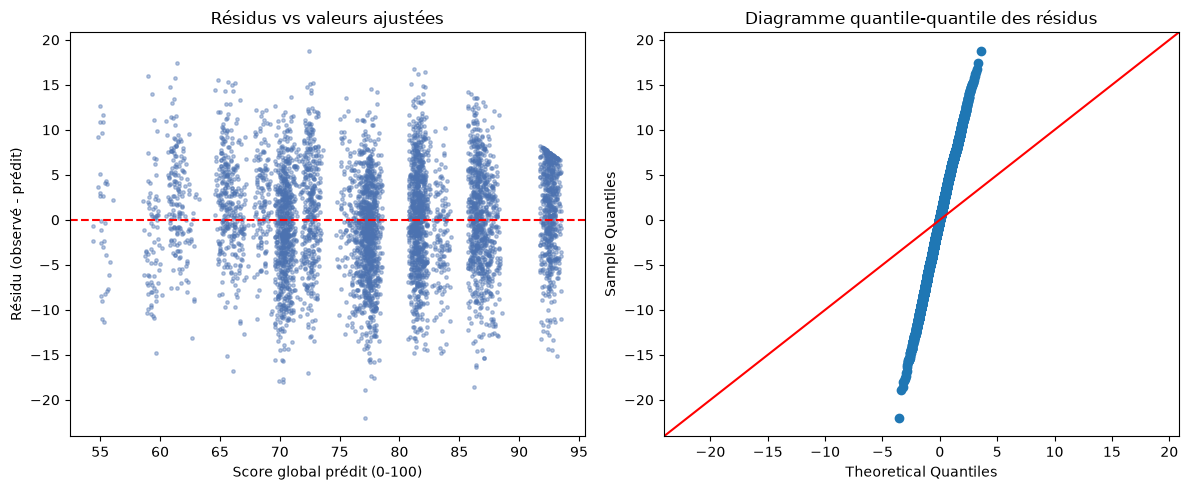

In [9]:
residus = result_ols.resid
valeurs_ajustees = result_ols.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(valeurs_ajustees, residus, s=6, alpha=0.4, color="#4C72B0")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Résidus vs valeurs ajustées")
axes[0].set_xlabel("Score global prédit (0-100)")
axes[0].set_ylabel("Résidu (observé - prédit)")

sm.qqplot(residus, line="45", ax=axes[1])
axes[1].set_title("Diagramme quantile-quantile des résidus")

fig.tight_layout()
fig.savefig(FIG_DIR / "06_diagnostics_ols.png")
plt.show()


**Interprétation.** Le nuage résidus-vs-ajustées ne montre pas de tendance forte (pas de courbure
évidente), ce qui est cohérent avec l'hypothèse de linéarité. Le diagramme quantile-quantile montre un
alignement globalement correct avec la diagonale, avec de légers écarts aux extrêmes, suggérant des
résidus proches de la normalité sans être parfaits. Ces diagnostics ne révèlent pas de violation majeure
justifiant d'écarter le modèle linéaire.

## 6. Sauvegarde du modèle retenu

In [10]:
chemin_modele = save_model(result_ols, "06_modele_ols_variable_cible")
print("Modèle sauvegardé :", chemin_modele)

resultat_structure = ModelResult(
    nom_modele="OLS (erreurs groupées par école) — variable_cible",
    formule=formule_ols,
    n_observations=int(result_ols.nobs),
    coefficients=tab_ols,
    metriques=metriques_ols,
    diagnostics={"icc_modele_mixte_comparatif": icc},
)
chemins_resume = save_model_summary(resultat_structure, "06_modele_ols_variable_cible")
print("Résumé sauvegardé :", chemins_resume)


Modèle sauvegardé : C:\Users\admin\Desktop\PROJET STATISTIQUE PUBLIC B\outputs\models\06_modele_ols_variable_cible.pickle
Résumé sauvegardé : {'json': WindowsPath('C:/Users/admin/Desktop/PROJET STATISTIQUE PUBLIC B/outputs/models/06_modele_ols_variable_cible_resume.json'), 'txt': WindowsPath('C:/Users/admin/Desktop/PROJET STATISTIQUE PUBLIC B/outputs/models/06_modele_ols_variable_cible_resume.txt')}


## 7. Synthèse

**RÉSULTAT global.** Le modèle retenu est une régression linéaire (OLS) de `variable_cible` sur `statut`,
`niveau`, `ips` et `dedoublement`, avec écarts-types groupés par école (R² ≈ 0,70). Un modèle à effets
mixtes a été estimé en comparaison et confirme que la structure hiérarchique école n'apporte que très
peu d'information supplémentaire (ICC ≈ 0,7 %) une fois `statut` et `ips` pris en compte.

**INTERPRÉTATION.** Le statut REP/REP+ reste associé à un score significativement plus faible que
Hors EP, même après contrôle de l'IPS et du niveau scolaire. L'écart ne disparaît donc pas simplement en
tenant compte du contexte social mesuré ici.

**SIGNIFICATION MÉTIER.** Ces résultats confirment, de façon associative, la persistance d'inégalités de
performance liées au statut d'éducation prioritaire, cohérente avec les constats DEPP évoqués en phase
de cadrage (notebook 00).

**LIMITES.**
- Ce modèle reste **associatif** : il ne permet pas d'isoler l'effet causal du dédoublement des classes
  lui-même, car `dedoublement` est structurellement confondu avec `statut` × `niveau` (il ne varie qu'en
  REP/REP+ CP/CE1).
- Les hypothèses de linéarité et de résidus approximativement normaux sont raisonnablement vérifiées,
  mais pas parfaitement (légers écarts aux extrêmes du QQ-plot).
- Les données utilisées sont simulées/reconstruites (voir notebook 01) : les magnitudes numériques
  précises ne doivent pas être interprétées comme des estimations officielles, seule la démarche
  méthodologique est transférable à des données réelles.
- L'identification d'un effet causal du dédoublement nécessite une méthode dédiée (différence-de-
  différences), prévue au notebook 09, en s'appuyant sur le déploiement progressif de la réforme
  (2017-2018 à 2019-2020) déjà documenté dans le notebook de cadrage.